# Rasterization

Raster creation and conversion from vector or matrix

## Settings

In [ ]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_subds <- NULL
param_lyrs <- NULL
param_nrows <- 100
param_ncols <- 300
param_nlyrs <- 1
param_xmin <- -150
param_xmax <- 150
param_ymin <- -50
param_ymax <- 50
param_crs <- "EPSG:28992"
param_resolution <- 1
param_values <- ceiling(255 * runif(100 * 300))
param_names <- "example"
param_time <- NULL
param_units <- NULL
param_field <- "NAME_2"
param_fun <- "sum"
param_background <- NA
param_touches <- FALSE
param_mode <- "binary"
param_group <- NULL
param_out <- tempdir()
param_overwrite <- TRUE

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Import raster from file

In [28]:
# GSTB import raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_subds: List
#    - param_lyrs: List
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be converted to raster
x <- in_raster

# Create raster
r <- rast(x          = x,
          subds      = param_subds,
          lyrs       = param_lyrs)

# Save to file
writeRaster(x         = r,
            filename  = paste0(param_out, "/imported_raster.tif"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "imported_raster.tif",
                  full.names = TRUE)

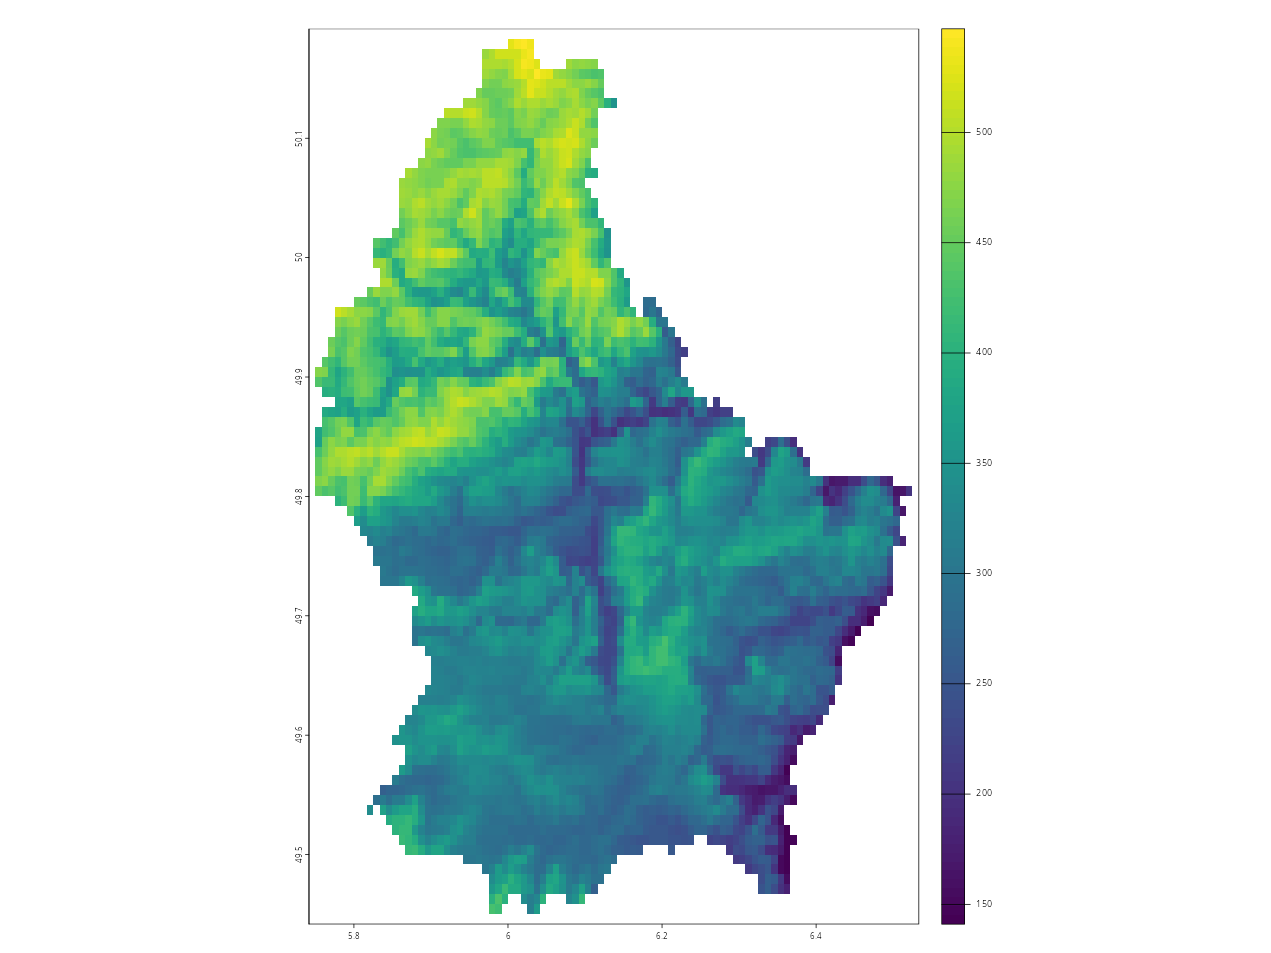

In [ ]:
plot(rast(out))

## Create raster from scratch

In [ ]:
# GSTB create raster
# NaaVRE:
#  cell:
#   params:
#    - param_nrows: Integer
#    - param_ncols: Integer
#    - param_nlyrs: Integer
#    - param_xmin: Float
#    - param_xmax: Float
#    - param_ymin: Float
#    - param_ymax: Float
#    - param_crs: String
#    - param_resolution: List
#    - param_values: List
#    - param_names: List
#    - param_time: List
#    - param_units: List
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Create raster
r <- rast(nrows      = param_nrows,
          ncols      = param_ncols,
          nlyrs      = param_nlyrs,
          xmin       = param_xmin,
          xmax       = param_xmax, 
          ymin       = param_ymin,
          ymax       = param_ymax,
          crs        = param_crs,
          resolution = param_resolution,
          vals       = param_values,
          names      = param_names,
          time       = param_time,
          units      = param_units)

# Save to file
writeRaster(x         = r,
            filename  = paste0(param_out, "/created_raster.tif"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "created_raster.tif",
                  full.names = TRUE)

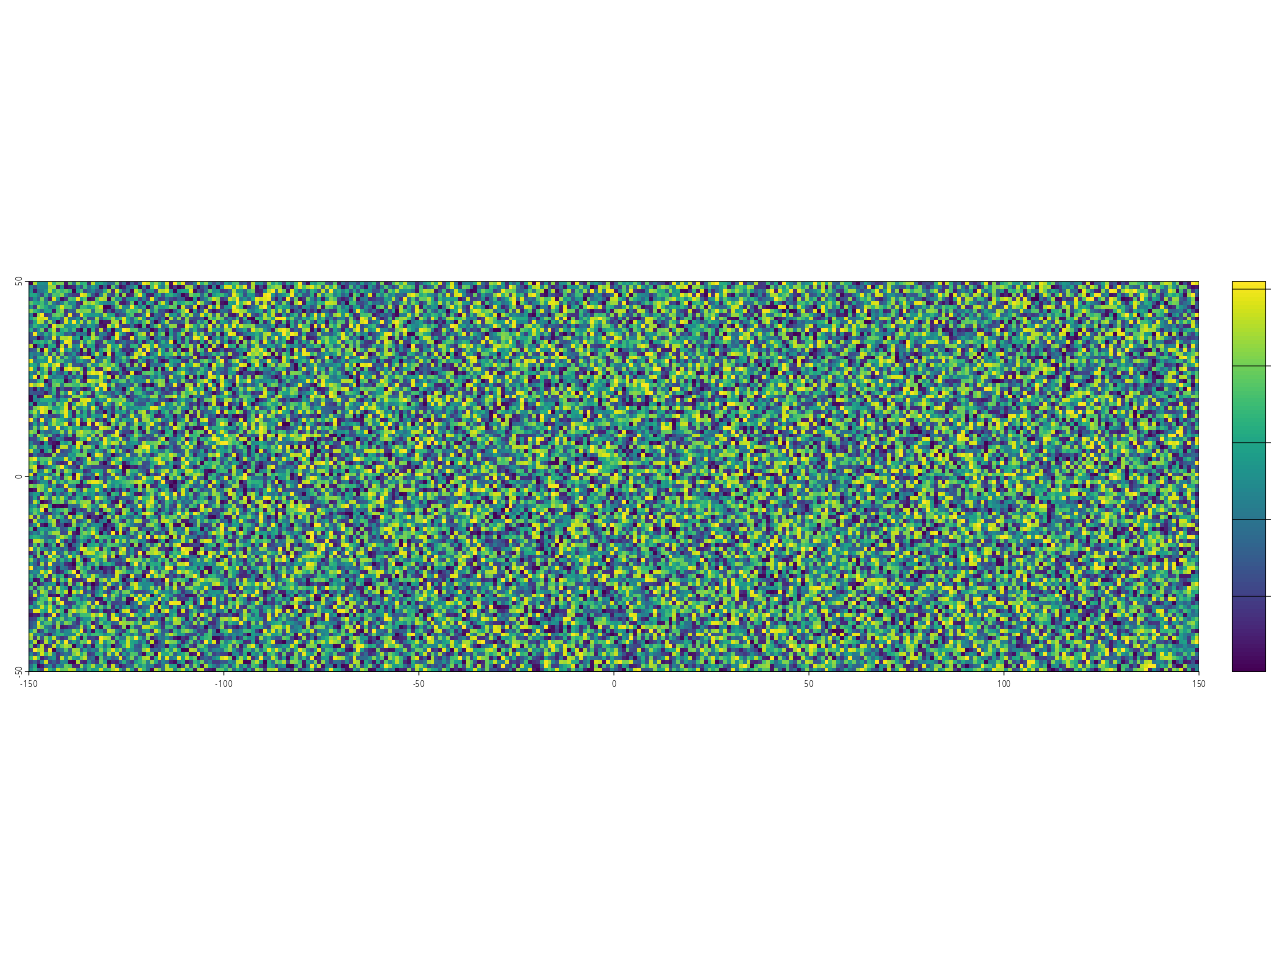

In [31]:
plot(rast(out))

## Rasterize vector data

Transfer values associated with the geometries of vector data to a raster

In [46]:
# GSTB rasterize vector
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#    - in_raster: String
#   params:
#    - param_field: String
#    - param_mode: String
#    - param_fun: String
#    - param_touches: Boolean
#    - param_group: String
#    - param_background: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# SpatVector to be rasterized
x <- vect(in_vector)

# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
} else {
  y <- rast(x, ncols = 100, nrows = 100)
}

# Rasterize
#   mode = "binary" : returns whether a cell is covered by the polygons
#   mode = "fraction" : returns the fraction of a cell that is covered by the polygons
if(param_mode == "binary") {
  rasterize(x          = x,
            y          = y,
            field      = param_field,
            fun        = param_fun,
            background = param_background,
            touches    = param_touches,
            update     = FALSE,
            cover      = FALSE,
            by         = param_group,
            filename   = paste0(param_out, "/rasterized_vector.tif"),
            overwrite  = TRUE)
} else if(param_mode == "fraction") {
  rasterize(x          = x,
            y          = y,
            field      = param_field,
            fun        = param_fun,
            background = param_background,
            touches    = param_touches,
            update     = FALSE,
            cover      = TRUE,
            by         = param_group,
            filename   = paste0(param_out, "/rasterized_vector.tif"),
            overwrite  = TRUE)
}

# Output
out <- list.files(path = param_out,
                  pattern = "rasterized_vector.tif",
                  full.names = TRUE)

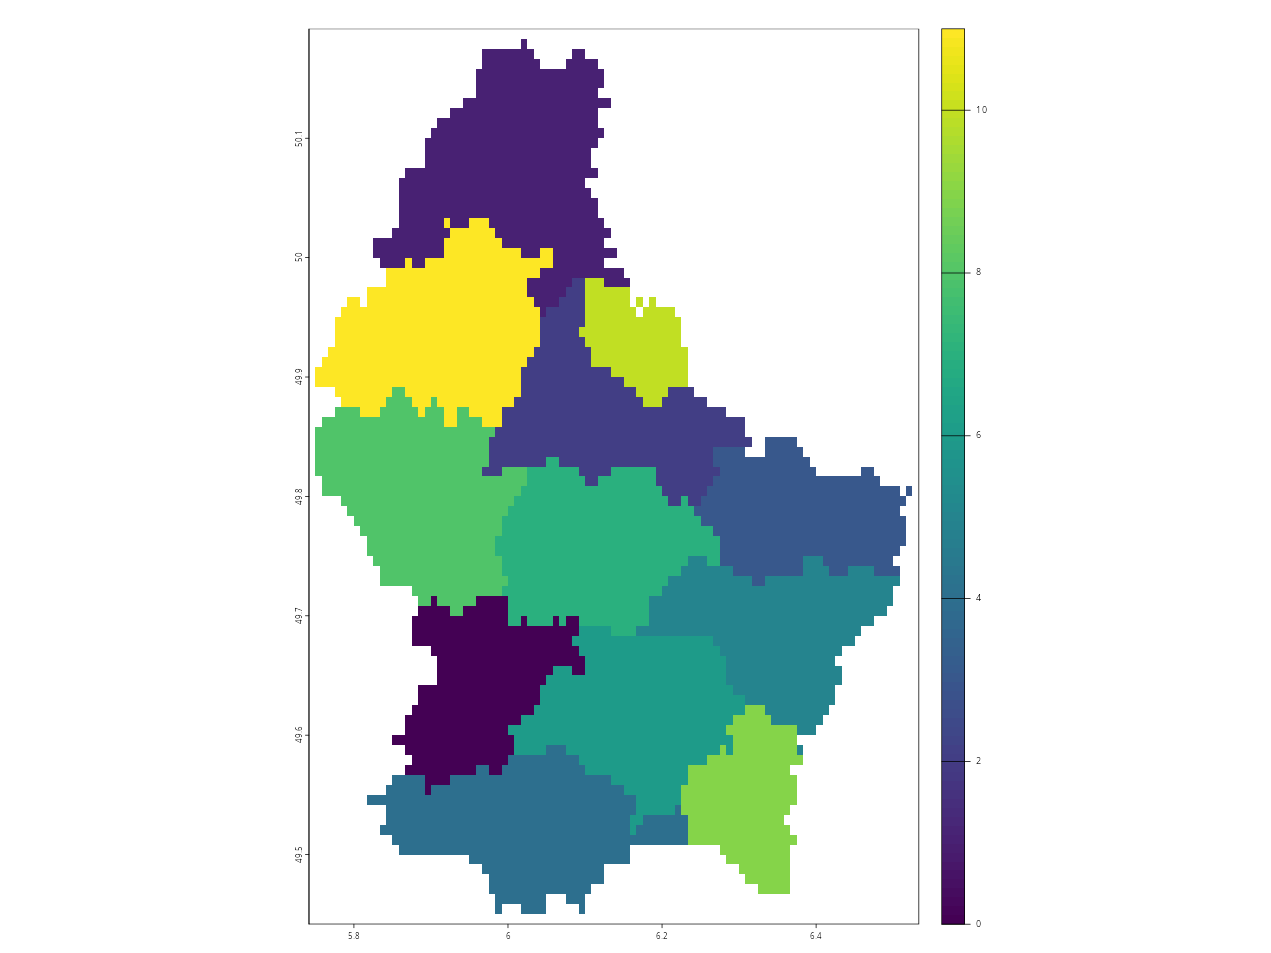

In [48]:
plot(rast(out))

## Rasterize matrix data

Transfer values associated with matrix data to a raster

In [ ]:
# GSTB rasterize matrix
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#    - in_raster: String
#   params:
#    - param_values: List
#    - param_fun: String
#    - param_background: String
#    - param_group: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Two-column matrix (point coordinates) or data.frame to be rasterized
x <- vect(in_vector, type = "points")
 
# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
}

# Rasterize
rasterize(x          = x,
          y          = y,
          values     = param_values,
          fun        = param_fun,
          background = param_background,
          update     = FALSE,
          by         = param_group,
          filename   = paste0(param_out, "/rasterized_matrix.tif"),
          overwrite  = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "rasterized_matrix.tif",
                  full.names = TRUE)